### Цель EDA:
понять структуру таблиц, необходимых для выполнения проекта по построению и оценке воронки обучения на задачах. 

В проекте будут использоваться таблицы: 
* Problem - характеристики задач: сложность, бонус, стоимость, рейтинг
* Language - справочник языков
* LanguageToProblem - допустимые языки для задач
* CodeRun - факт запуска кода
* CodeSubmit - факт отправки решения на проверку, результат проверки, язык

Подробное описание полного датасета и приведенных таблиц можно найти тут: [описание датасета](../dataset_description.md)

ERD-диаграмма находится [здесь](../pics/ERD_IT_Resume.jpg)

In [1]:
import pandas as pd

In [5]:
coderun = pd.read_csv('../raw_data/coderun_202604062047.csv')
codesubmit = pd.read_csv('../raw_data/codesubmit_202604062047.csv')
language = pd.read_csv('../raw_data/language_202604062045.csv')
languagetoproblem = pd.read_csv('../raw_data/languagetoproblem_202604062046.csv')
problem = pd.read_csv('../raw_data/problem_202604062044.csv')

In [8]:
print(f'coderun: {coderun.shape}')
print(f'codesubmit: {codesubmit.shape}')
print(f'language: {language.shape}')
print(f'languagetoproblem: {languagetoproblem.shape}')
print(f'problem: {problem.shape}')

coderun: (55722, 5)
codesubmit: (23768, 8)
language: (6, 2)
languagetoproblem: (248, 3)
problem: (248, 15)


In [9]:
coderun.info()

<class 'pandas.DataFrame'>
RangeIndex: 55722 entries, 0 to 55721
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           55722 non-null  int64
 1   created_at   55722 non-null  str  
 2   problem_id   55722 non-null  int64
 3   user_id      55722 non-null  int64
 4   language_id  55722 non-null  int64
dtypes: int64(4), str(1)
memory usage: 2.1 MB


In [17]:
coderun['created_at'] = pd.to_datetime(coderun['created_at'])

In [21]:
coderun['id'].is_unique

True

In [23]:
print('Min date:', coderun['created_at'].min())
print('Max date:', coderun['created_at'].max())

Min date: 2021-03-27 17:55:11
Max date: 2022-05-17 09:03:57.645000


In [ ]:
coderun[~coderun['problem_id'].isin(problem['id'])].empty

# нет запусков по задачам, которых нет в таблице problem

True

In [ ]:
coderun[~coderun['language_id'].isin(language['id'])].empty

# нет запусков по языкам, которых нет в таблице language

True

In [44]:
# распределение числа запусков на задачу
coderun['problem_id'].value_counts().describe()

count     244.000000
mean      228.368852
std       430.865025
min         1.000000
25%        20.750000
50%        55.500000
75%       276.500000
max      4063.000000
Name: count, dtype: float64

Text(0, 0.5, 'Количество задач')

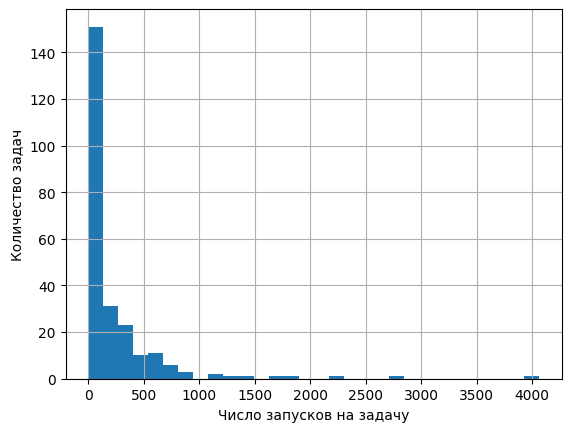

In [54]:
coderun_problem_hist = coderun['problem_id'].value_counts().hist(bins=30)
coderun_problem_hist.set_xlabel('Число запусков на задачу')
coderun_problem_hist.set_ylabel('Количество задач')

In [46]:
# распределение числа запусков на пользователя
coderun['user_id'].value_counts().describe()

count     868.000000
mean       64.195853
std       140.361647
min         1.000000
25%         4.000000
50%        14.000000
75%        60.250000
max      1466.000000
Name: count, dtype: float64

Text(0, 0.5, 'Количество пользователей')

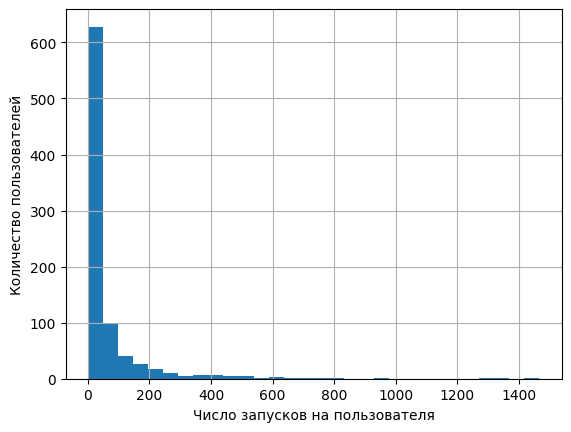

In [47]:
coderun_user_hist = coderun['user_id'].value_counts().hist(bins=30)
coderun_user_hist.set_xlabel('Число запусков на пользователя')
coderun_user_hist.set_ylabel('Количество пользователей')

In [36]:
# распределение числа запусков на язык
coderun['language_id'].value_counts()

language_id
2    44483
3    11239
Name: count, dtype: int64

In [48]:
coderun['language_id'].value_counts(normalize=True, dropna=False)

language_id
2    0.798302
3    0.201698
Name: proportion, dtype: float64

Таблица `coderun` содержит 55 722 корректных записей о запусках кода за период с 27.03.2021 по 17.05.2022. Пропусков и нарушений ссылочной целостности не выявлено. Распределение запусков по задачам и пользователям сильно скошено вправо: большинство задач и пользователей имеют сравнительно небольшое число запусков, тогда как небольшое число задач и пользователей формирует основную активность. По языкам программирования наблюдается доминирование одного языка: на него приходится около 80% всех запусков.

In [10]:
codesubmit.info()

<class 'pandas.DataFrame'>
RangeIndex: 23768 entries, 0 to 23767
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           23768 non-null  int64  
 1   created_at   23768 non-null  str    
 2   code         23704 non-null  str    
 3   problem_id   23768 non-null  int64  
 4   user_id      23768 non-null  int64  
 5   is_false     23768 non-null  int64  
 6   time_spent   22738 non-null  float64
 7   language_id  23768 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 1.5 MB


In [11]:
language.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      6 non-null      int64
 1   name    6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 228.0 bytes


In [12]:
languagetoproblem.info()

<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ltp_id   248 non-null    int64
 1   pr_id    248 non-null    int64
 2   lang_id  248 non-null    int64
dtypes: int64(3)
memory usage: 5.9 KB


In [13]:
problem.info()

<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              248 non-null    int64  
 1   name            248 non-null    str    
 2   complexity      248 non-null    int64  
 3   bonus           248 non-null    int64  
 4   task            248 non-null    str    
 5   solution        248 non-null    str    
 6   cost            248 non-null    int64  
 7   rating          242 non-null    float64
 8   page_id         248 non-null    int64  
 9   solution_cost   248 non-null    int64  
 10  priority        248 non-null    float64
 11  company_id      0 non-null      float64
 12  is_visible      248 non-null    bool   
 13  is_private      248 non-null    bool   
 14  recommendation  0 non-null      float64
dtypes: bool(2), float64(4), int64(6), str(3)
memory usage: 25.8 KB
